In [6]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np
import re


# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define data paths
BASE_DIR = Path("data/MultiTaskVideoReasoning")
MTVR_COT_DIR = BASE_DIR / "MTVR_CoT"
MTVR_TOOL_COT_DIR = BASE_DIR / "MTVR_Tool_CoT"

print("✅ Imports successful!")
print(f"📂 Base directory: {BASE_DIR}")


✅ Imports successful!
📂 Base directory: data/MultiTaskVideoReasoning


In [7]:
mtvr_cot_data.keys()

dict_keys([])

In [8]:
mtvr_cot_data['Video-R1-data-video'][0].keys()

KeyError: 'Video-R1-data-video'

In [9]:
# Load all MTVR_CoT datasets
def load_json_file(filepath):
    """Load a JSON file and return its contents."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

# Load MTVR_CoT data
mtvr_cot_data = {}
for json_file in MTVR_COT_DIR.glob("*.json"):
    dataset_name = json_file.stem
    data = load_json_file(json_file)
    mtvr_cot_data[dataset_name] = data
    print(f"📊 Loaded {dataset_name}: {len(data)} samples")

# Load MTVR_Tool_CoT data
mtvr_tool_cot_data = {}
for json_file in MTVR_TOOL_COT_DIR.glob("*.json"):
    dataset_name = json_file.stem
    data = load_json_file(json_file)
    mtvr_tool_cot_data[dataset_name] = data
    print(f"🛠️ Loaded Tool-CoT {dataset_name}: {len(data)} samples")

print(f"\n✅ Total MTVR_CoT datasets: {len(mtvr_cot_data)}")
print(f"✅ Total MTVR_Tool_CoT datasets: {len(mtvr_tool_cot_data)}")


📊 Loaded Video-R1-data-video: 6993 samples
📊 Loaded longvideo-reason: 7626 samples
📊 Loaded charades: 10608 samples
📊 Loaded actnet: 9494 samples
📊 Loaded Video-R1-data-image: 8065 samples
📊 Loaded rextime: 3666 samples
📊 Loaded nextgqa: 3021 samples
📊 Loaded vidchapters: 4257 samples
🛠️ Loaded Tool-CoT longvideo-reason: 7019 samples
🛠️ Loaded Tool-CoT vidchapters: 10571 samples

✅ Total MTVR_CoT datasets: 8
✅ Total MTVR_Tool_CoT datasets: 2


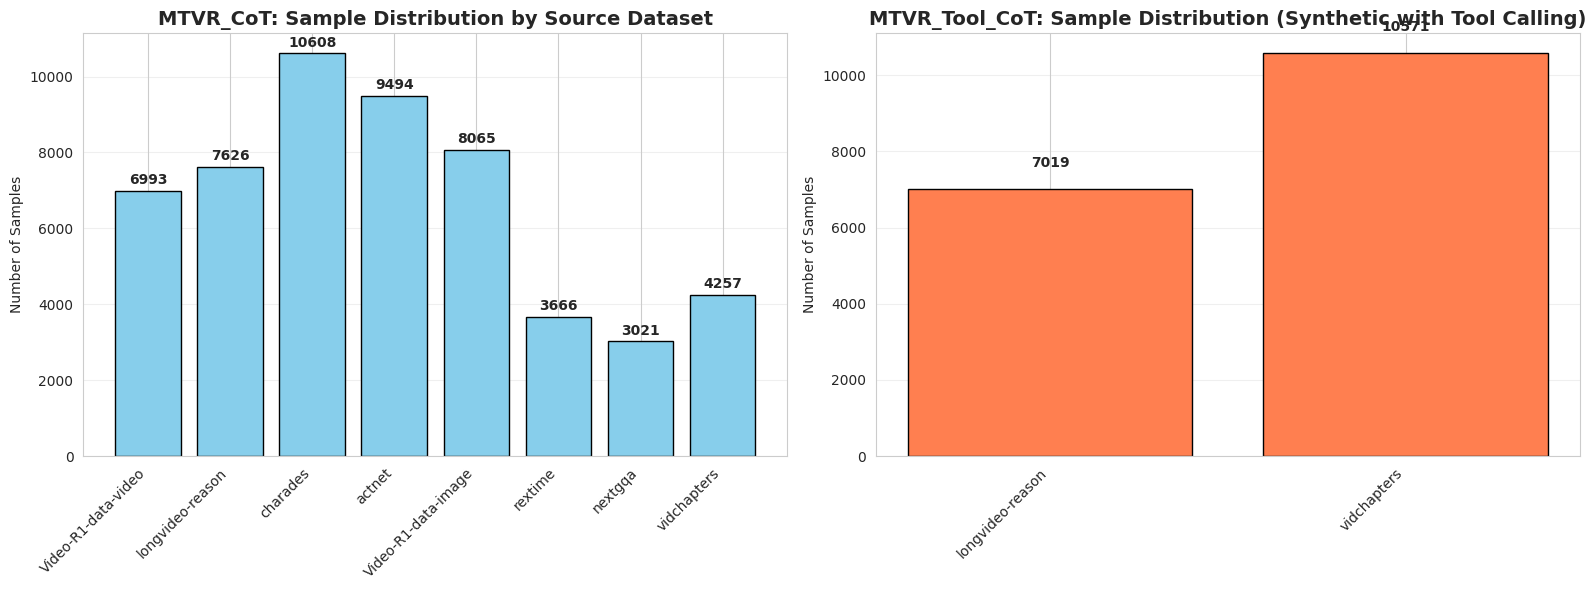


📈 DATASET SIZE SUMMARY
Total MTVR_CoT samples: 53,730
Total MTVR_Tool_CoT samples: 17,590
Grand Total: 71,320


In [10]:
# Visualization 1: Distribution of samples across source datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MTVR_CoT distribution
cot_counts = {k: len(v) for k, v in mtvr_cot_data.items()}
axes[0].bar(range(len(cot_counts)), list(cot_counts.values()), color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(cot_counts)))
axes[0].set_xticklabels(list(cot_counts.keys()), rotation=45, ha='right')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('MTVR_CoT: Sample Distribution by Source Dataset', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(cot_counts.values()):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontweight='bold')

# MTVR_Tool_CoT distribution
tool_cot_counts = {k: len(v) for k, v in mtvr_tool_cot_data.items()}
axes[1].bar(range(len(tool_cot_counts)), list(tool_cot_counts.values()), color='coral', edgecolor='black')
axes[1].set_xticks(range(len(tool_cot_counts)))
axes[1].set_xticklabels(list(tool_cot_counts.keys()), rotation=45, ha='right')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('MTVR_Tool_CoT: Sample Distribution (Synthetic with Tool Calling)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(tool_cot_counts.values()):
    axes[1].text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("📈 DATASET SIZE SUMMARY")
print("="*60)
print(f"Total MTVR_CoT samples: {sum(cot_counts.values()):,}")
print(f"Total MTVR_Tool_CoT samples: {sum(tool_cot_counts.values()):,}")
print(f"Grand Total: {sum(cot_counts.values()) + sum(tool_cot_counts.values()):,}")
print("="*60)

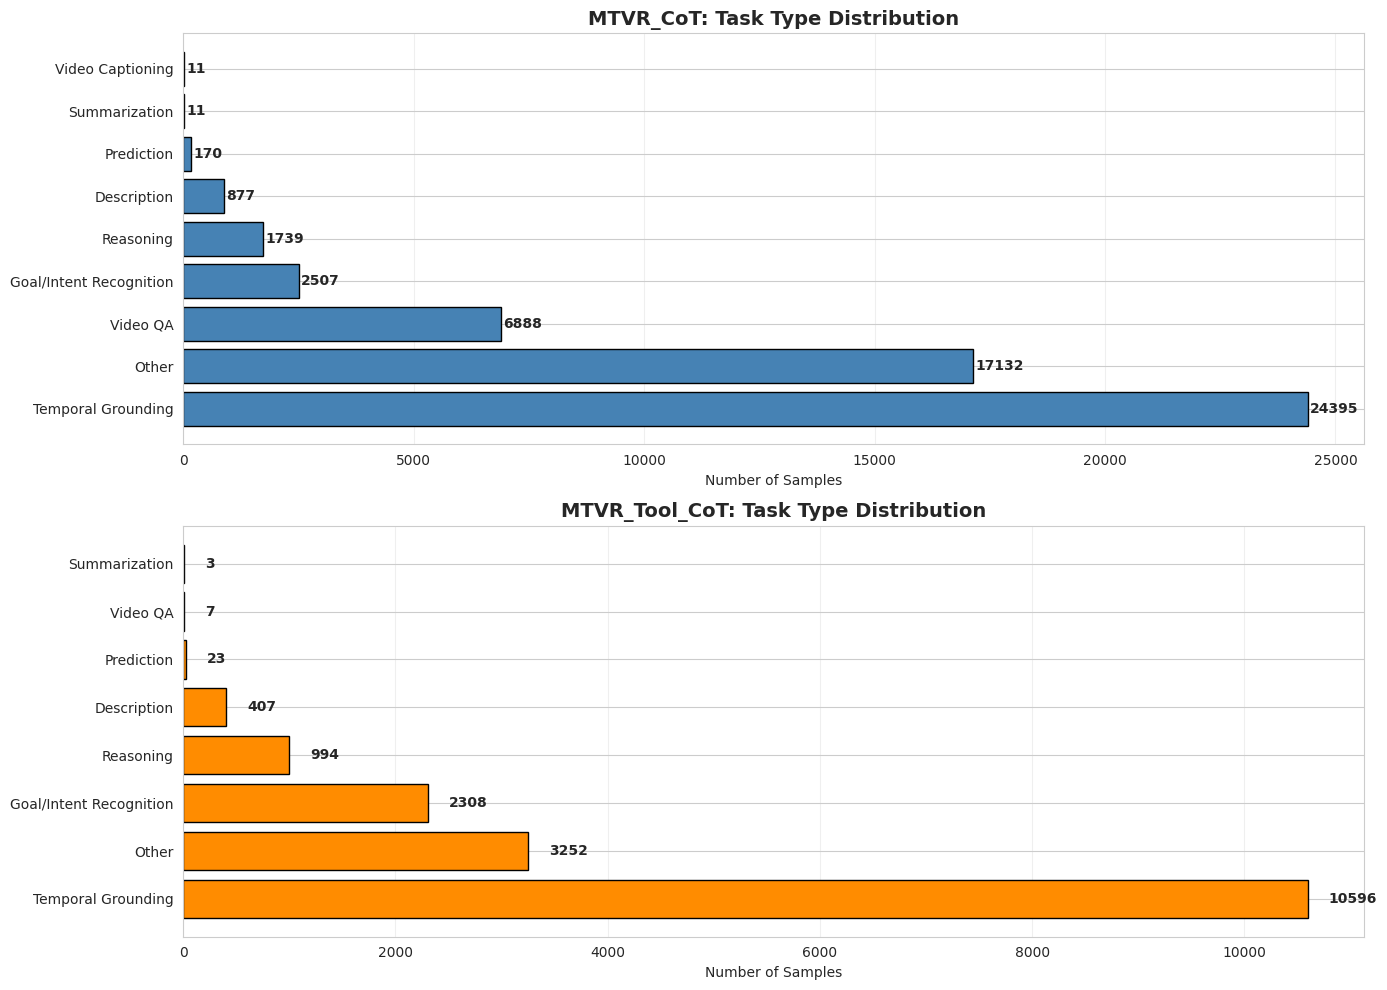


🎯 TASK TYPE BREAKDOWN

MTVR_CoT:
task_type
Temporal Grounding         24395
Other                      17132
Video QA                    6888
Goal/Intent Recognition     2507
Reasoning                   1739
Description                  877
Prediction                   170
Summarization                 11
Video Captioning              11
Name: count, dtype: int64

MTVR_Tool_CoT:
task_type
Temporal Grounding         10596
Other                       3252
Goal/Intent Recognition     2308
Reasoning                    994
Description                  407
Prediction                    23
Video QA                       7
Summarization                  3
Name: count, dtype: int64


In [11]:
# Visualization 2: Task Type Analysis
# Extract task types from the text field

def extract_task_type(text):
    """Extract task type from the instruction text."""
    text_lower = text.lower()
    
    # Define task patterns
    if 'temporal' in text_lower or 'starting and ending times' in text_lower or 'start time and end time' in text_lower:
        return 'Temporal Grounding'
    elif 'caption' in text_lower:
        return 'Video Captioning'
    elif 'question' in text_lower and 'answer' in text_lower:
        return 'Video QA'
    elif 'summarize' in text_lower or 'summary' in text_lower:
        return 'Summarization'
    elif 'reasoning' in text_lower or 'inferred' in text_lower or 'why' in text_lower:
        return 'Reasoning'
    elif 'describe' in text_lower:
        return 'Description'
    elif 'predict' in text_lower or 'what will' in text_lower:
        return 'Prediction'
    elif 'goal' in text_lower or 'intention' in text_lower or 'purpose' in text_lower:
        return 'Goal/Intent Recognition'
    else:
        return 'Other'

# Analyze task types in MTVR_CoT
task_types_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        task_type = extract_task_type(sample.get('text', ''))
        task_types_cot.append({'dataset': dataset_name, 'task_type': task_type})

df_tasks_cot = pd.DataFrame(task_types_cot)

# Analyze task types in MTVR_Tool_CoT
task_types_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        task_type = extract_task_type(sample.get('text', ''))
        task_types_tool.append({'dataset': dataset_name, 'task_type': task_type})

df_tasks_tool = pd.DataFrame(task_types_tool)

# Create visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Task type distribution in MTVR_CoT
task_counts_cot = df_tasks_cot['task_type'].value_counts()
axes[0].barh(range(len(task_counts_cot)), task_counts_cot.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(task_counts_cot)))
axes[0].set_yticklabels(task_counts_cot.index)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('MTVR_CoT: Task Type Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(task_counts_cot.values):
    axes[0].text(v + 50, i, str(v), va='center', fontweight='bold')

# Task type distribution in MTVR_Tool_CoT
task_counts_tool = df_tasks_tool['task_type'].value_counts()
axes[1].barh(range(len(task_counts_tool)), task_counts_tool.values, color='darkorange', edgecolor='black')
axes[1].set_yticks(range(len(task_counts_tool)))
axes[1].set_yticklabels(task_counts_tool.index)
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('MTVR_Tool_CoT: Task Type Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, v in enumerate(task_counts_tool.values):
    axes[1].text(v + 200, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🎯 TASK TYPE BREAKDOWN")
print("="*60)
print("\nMTVR_CoT:")
print(task_counts_cot)
print("\nMTVR_Tool_CoT:")
print(task_counts_tool)
print("="*60)


In [27]:
from yt_dlp import YoutubeDL

def get_youtube_duration(video_id: str) -> float:
    url = f"https://www.youtube.com/watch?v={video_id}"
    ydl_opts = {"quiet": True, "skip_download": True}
    with YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)
        return info["duration"]  # duration in seconds

print(get_youtube_duration("dQw4w9WgXcQ"))


213


In [28]:
mtvr_cot_data['longvideo-reason']

[{'id': '011600',
  'video': '7mfJRMzezdg.mp4',
  'text': 'What is the man\'s primary intention in combining the demonstration of cupcake preparation steps with the repeated display of "The Scran Line" branding and the "Subscribe" prompt toward the end of the video?  \nA. To sell the cupcakes directly to viewers through his website.  \nB. To establish credibility as a chef by showcasing his kitchen setup.  \nC. To encourage viewers to recreate the recipe independently without further engagement.  \nD. To grow his culinary brand’s audience by driving traffic to his platform and fostering loyalty.  \n',
  'solution': '<think>The man\'s role as a host and chef is accentuated by his attire (striped shirt and apron), expressive gestures, and kitchen setting, all aligned with "The Scran Line" branding. This establishes him as the face of a culinary brand. The detailed arrangement of ingredients and the step-by-step baking process further highlight his expertise, building trust and interest i

/tmp/ipykernel_684975/34987750.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_durations_cot, x='dataset', y='duration', ax=axes[0], palette='Set2')
/tmp/ipykernel_684975/34987750.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_durations_tool, x='dataset', y='duration', ax=axes[1], palette='Set1')


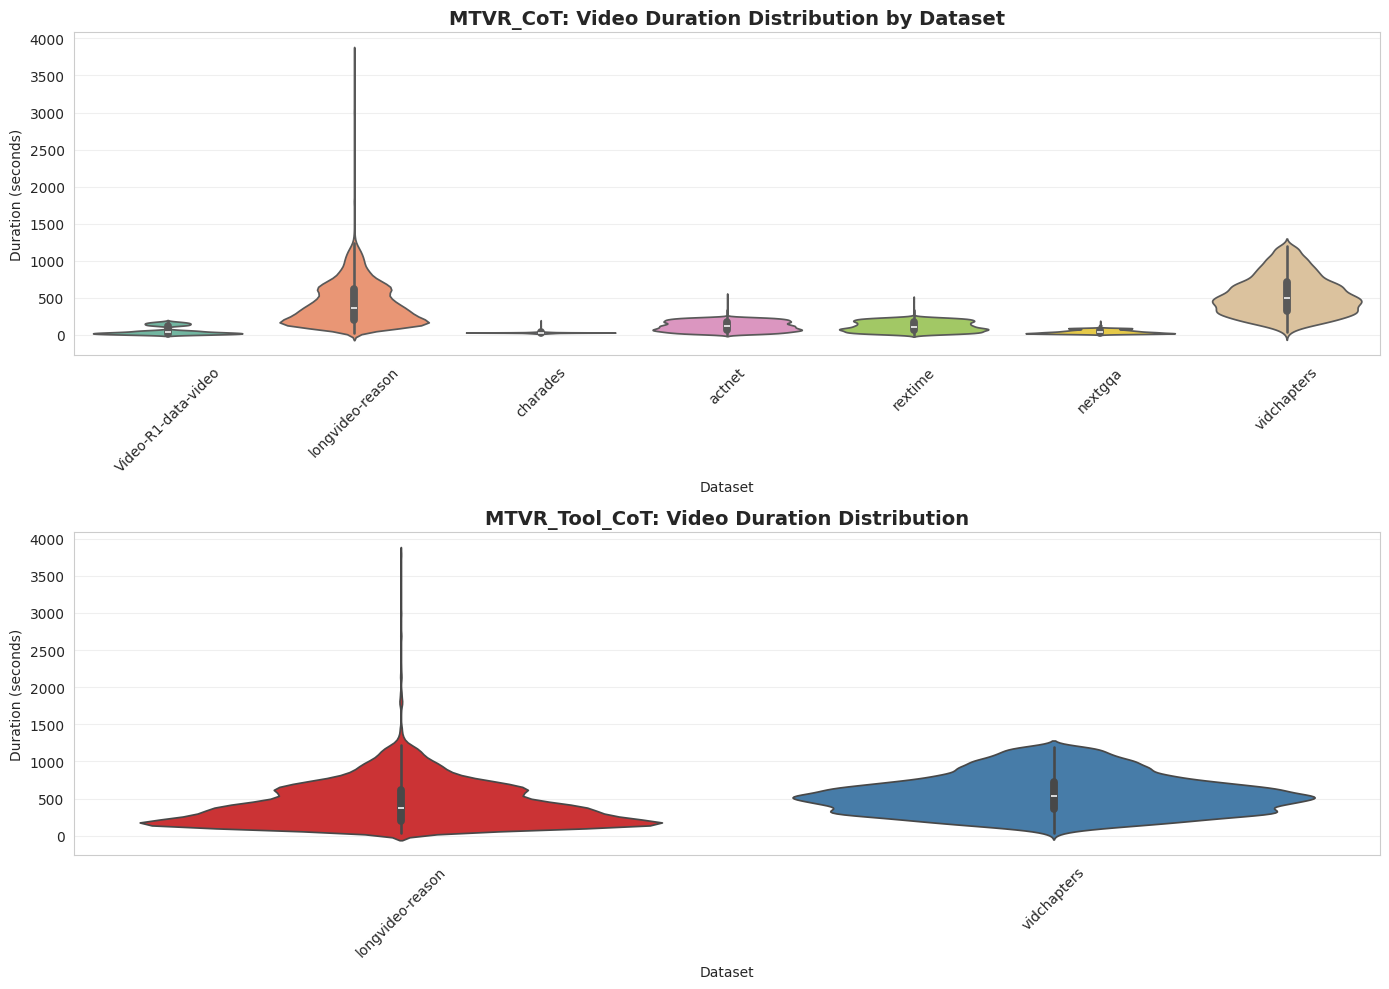


⏱️ VIDEO DURATION STATISTICS

MTVR_CoT:
                       count        mean         std    min       25%  \
dataset                                                                 
Video-R1-data-video   6993.0   59.325254   56.051397   5.00   17.5000   
actnet                9494.0  120.921072   65.433026   2.56   65.6700   
charades             10608.0   31.291819    9.271381   5.53   28.4400   
longvideo-reason      7626.0  434.935084  299.448788  28.79  198.8050   
nextgqa               3021.0   43.352863   24.995456  10.00   22.0000   
rextime               3666.0  116.890900   67.003270   1.58   60.3425   
vidchapters           4257.0  537.828283  262.784372  32.00  328.0000   

                         50%       75%      max  
dataset                                          
Video-R1-data-video   32.500  123.5000   180.00  
actnet               117.890  176.2550   536.87  
charades              30.760   32.9100   194.39  
longvideo-reason     363.280  614.1325  3783.84  
n

In [38]:
# Visualization 3: Video Duration Analysis
durations_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        if 'video' not in sample:
            continue
        if 'duration' in sample:
            durations_cot.append({
                'id': sample['id'],
                'video_id': sample['video'].split('.')[0],
                'dataset': dataset_name,
                'duration': sample['duration'],
            })

df_durations_cot = pd.DataFrame(durations_cot)

durations_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        if 'duration' in sample:
            durations_tool.append({
                'id': sample['id'],
                'video_id': sample['video'].split('.')[0],
                'dataset': dataset_name,
                'duration': sample['duration']
            })

df_durations_tool = pd.DataFrame(durations_tool)

# Create violin plots for duration distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# MTVR_CoT duration distribution
if not df_durations_cot.empty:
    sns.violinplot(data=df_durations_cot, x='dataset', y='duration', ax=axes[0], palette='Set2')
    axes[0].set_title('MTVR_CoT: Video Duration Distribution by Dataset', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('Duration (seconds)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

# MTVR_Tool_CoT duration distribution
if not df_durations_tool.empty:
    sns.violinplot(data=df_durations_tool, x='dataset', y='duration', ax=axes[1], palette='Set1')
    axes[1].set_title('MTVR_Tool_CoT: Video Duration Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('Duration (seconds)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("⏱️ VIDEO DURATION STATISTICS")
print("="*60)
if not df_durations_cot.empty:
    print("\nMTVR_CoT:")
    print(df_durations_cot.groupby('dataset')['duration'].describe())
if not df_durations_tool.empty:
    print("\nMTVR_Tool_CoT:")
    print(df_durations_tool.groupby('dataset')['duration'].describe())
print("="*60)


8002

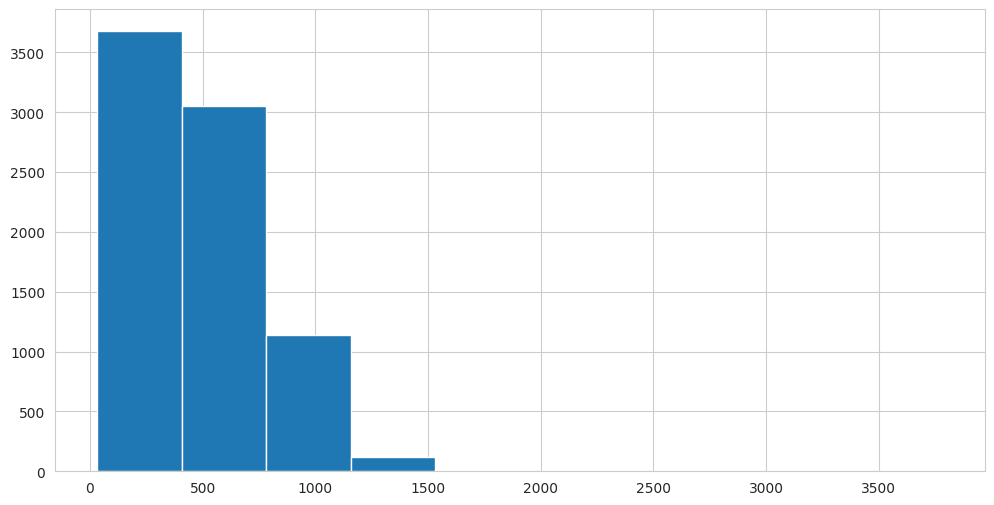

In [45]:
all_unique_durations = df_durations_tool.groupby('video_id')['duration'].mean()

plt.hist(all_unique_durations)

len(all_unique_durations)

In [60]:
all_unique_durations[all_unique_durations < 1000].sum()

np.float64(3347499.55)

In [47]:
(all_unique_durations > 1000).sum()

np.int64(480)

In [48]:
with open("/data/user_data/jamesdin/data/vidchapters/test_video_ids.json", "rb") as f:
    test_video_ids = json.load(f)

In [ ]:
all_unique_ids = set(all_unique_durations.index)
count = 0
for vid in test_video_ids:
    if vid not in all_unique_ids:
        count += 1
    

In [52]:
count

8199

In [11]:
import json
with open('data/MultiTaskVideoReasoning/MTVR_Tool_CoT/longvideo-reason.json') as f:
    data1 = json.load(f)

import json
with open('data/MultiTaskVideoReasoning/MTVR_Tool_CoT/vidchapters.json') as f:
    data2 = json.load(f)

import json
with open('data/MultiTaskVideoReasoning/MTVR_Tool_RL/longvideo-reason.json') as f:
    data3 = json.load(f)

import json
with open('data/MultiTaskVideoReasoning/MTVR_Tool_RL/vidchapters.json') as f:
    data4 = json.load(f)


unique_vid1 = set([d['video'] for d in data1])
unique_vid2 = set([d['video'] for d in data2])
unique_vid3 = set([d['video'] for d in data3])
unique_vid4 = set([d['video'] for d in data4])

In [15]:
len(unique_vid1), len(unique_vid2), len(unique_vid3), len(unique_vid4)

(5266, 2737, 5769, 2963)

In [12]:
len(unique_vid1.union(unique_vid2))

8002

In [13]:
len(unique_vid4.union(unique_vid3))

8731

In [ ]:
unique_vid = set([d['video'] for d in data])
len(unique_vid)  # this we have 1531


1829

In [61]:
import json
datas = []
with open('/data/user_data/jamesdin/data/longvideo-reason/test.jsonl') as f:
    for line in f:
        data = json.loads(line)
        datas.append(data)

In [71]:
for d in datas:
    vid = d['videos'].split('/')[-1].split('.')[0]
    print(vid)

I_Q3ajyOrcI
8kaV6kb7vZo
NDqibzGrTt8
KVrItY5wtDs
Wznd1nIw74M
IsZ2dkquLVI
186O2SrBOQs
5xM3HHUCZdQ
-a34tO5OKjY
qj4cQh7pZVI
dDXxzGW3r4w
mdj9LBPkEhQ
_HYAs0PK8fk
JHyAEFQCb-4
derWokOp5C4
2EgI6VbugFA
dI3W7IcJXEI
0ImeVjLxnSo
DkIE2Ck8Tuc
dD51GzQJRmo
EGIAAgHPsqQ
MUybRu_JXJY
8E80A8-KKSY
YlZznuFGWEI
NYifTXGwCOM
YEnnt96mzi4
erCCIZLOnVI
G2W6C2qnzSU
BmvQ_AhEAp4
1Evj5XMTWEo
4mqO4gaQBfY
4-kuDpm5StU
_dncs2stX-w
6Q-UeuliYpk
LdvJ591PyrQ
LyX5yW9m9jM
MpAEfzf3Hk0
f3Y142xBeko
pKJC94acRiE
58pMwCBXyxQ
Z9j6Osc8zw4
E-iu0DFngT0
P5B0LjVS05s
M9V3NtK-4nM
EU3xftgBhU4
2JbzvSvpdtE
MnFJTo3AVHI
_RaKqKrDXW4
g2BXEZSCod0
NhG_Nap9-C8
PKxn9YzLJoo
nOJDSgUdbCg
7WHI2L_FDNg
Fz6MN7XJTmw
rDWylXu7CDA
GznQgTdEdI4
lhlfw9IVygs
D12DSr2SVfk
4Q2VTBUJyak
3cuB7gcCTio
fltZQ73OqRs
NXPaB9Mhacs
ETWBSzZFl0Q
DkIWktzsSzA
_czhNhBXOD0
fE0LOM27PKY
f127AtJtETo
j9B9HLobBzs
k3bSYJj6knA
oMtaeizPkFs
PL-LJKuxfCc
YWsMvxHhzZQ
mVvAik4recM
GlU1waMbF0Y
l4iVhzeegyk
BPrRCVZFttg
MbMOGovnRdo
qICzdC0pCAg
BoFGd2zPvpA
VJ1LhF0nGZc
PXorXI6lMRQ
iu3QbkhR5ME
0wM4B7DONu0
XQWz

In [77]:
testfile_path = '/data/user_data/jamesdin/data/vidchapters/test.jsonl'

datas = []
with open(testfile_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        datas.append(data)
        


In [82]:
vids = [data['vid'] for data in datas]
unique_vids = set(vids)
len(unique_vids)
unique_vids


{'3kmhwkoGYbSU',
 '47x6qgh4aioW8',
 '6ysIhGuou4yM',
 '11B0AZ3Q2nMyM',
 '84ifyA6plCbI',
 '123-7uR3hJR-0',
 '4XsI_I1Hp-o0',
 '3wtLOzMisBGw',
 '4fvVXKE-WVx0',
 '84VZwuPCYhSg',
 '11QNNOlDzzYZc',
 '2loDSOAJFgt0',
 '11T-yCiN08mV0',
 '1rnkzmGhsLfo',
 '1-_0Uqu-6rOM',
 '0I7QjI-plQp0',
 '20NW_9B1axjc',
 '12ccTBv5lLmOc',
 '2Gu2MksdTmgQ',
 '21H9cF85GUPbw',
 '10TC1rKEeKxVg',
 '4OYCSXrewkD4',
 '3T2YP26o1rSI',
 '1O7U5Rw-5vOM',
 '12tgGfVFhRyrw',
 '1GD3SuDEU93U',
 '0uWDWtFK3NWM',
 '8w9yO0uqY-ZI',
 '1NO6N185jLRA',
 '2X5gnQ9f32qw',
 '0KUEUxScDSXE',
 '0_EF1ot9_gp8',
 '190bTY9YtVuc',
 '0f_zuEyM4ghI',
 '5cY5OubNf9LY',
 '2M08Jl5uROMw',
 '8P6xkJ8sSrUA',
 '5tG-YNxtT6bs',
 '4g5czD56QLk8',
 '12USSCvwEzY2s',
 '5oQdXzOGk0aY',
 '4SGU3kq7bQv0',
 '7gmJjsSsPvwk',
 '6-bfuVNoD7o0',
 '2_3txiz53JPE',
 '3766yktQQJ4k',
 '34cBX4P306KzY',
 '3KE4fHAYG4b0',
 '1qMQb9zWe-og',
 '10rfcovDT9Kmc',
 '4YNiFcOlh5v8',
 '08-WQZ4YSGFo',
 '7ZPNOrMe8PpY',
 '1joxbpqLvSwQ',
 '2Yk6HnxKga9g',
 '1toG9VFiWgPg',
 '2-9Mc51-OVyg',
 '2ngrxngtIn3E',
 '

In [68]:
count = 0
durations = []
for d in datas:
    vid = d['videos'].split('/')[-1].split('.')[0]
    try:
        duration = get_youtube_duration(vid)
        durations.append(duration)
    except Exception as e:
        print(e)
        count += 1
count



ERROR: [youtube] Wznd1nIw74M: Video unavailable. This video is no longer available due to a copyright claim by Trailer Park Boys


ERROR: [youtube] Wznd1nIw74M: Video unavailable. This video is no longer available due to a copyright claim by Trailer Park Boys


ERROR: [youtube] NhG_Nap9-C8: Video unavailable


ERROR: [youtube] NhG_Nap9-C8: Video unavailable


ERROR: [youtube] FyHyre4S5PA: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


...

ERROR: [youtube:truncated_id] 26_0: Incomplete YouTube ID 26_0. URL https://www.youtube.com/watch?v=26_0 looks truncated.
ERROR: [youtube:truncated_id] 71_0: Incomplete YouTube ID 71_0. URL https://www.youtube.com/watch?v=71_0 looks truncated.
ERROR: [youtube:truncated_id] 291_0: Incomplete YouTube ID 291_0. URL https://www.youtube.com/watch?v=291_0 looks truncated.
ERROR: [youtube:truncated_id] 393_1: Incomplete YouTube ID 393_1. URL https://www.youtube.com/watch?v=393_1 looks truncated.
ERROR: [youtube:truncated_id] 253_0: Incomplete YouTube ID 253_0. URL https://www.youtube.com/watch?v=253_0 looks truncated.
ERROR: [youtube:truncated_id] 101_5: Incomplete YouTube ID 101_5. URL https://www.youtube.com/watch?v=101_5 looks truncated.


ERROR: [youtube:truncated_id] 26_0: Incomplete YouTube ID 26_0. URL https://www.youtube.com/watch?v=26_0 looks truncated.
ERROR: [youtube:truncated_id] 71_0: Incomplete YouTube ID 71_0. URL https://www.youtube.com/watch?v=71_0 looks truncated.
ERROR: [youtube:truncated_id] 291_0: Incomplete YouTube ID 291_0. URL https://www.youtube.com/watch?v=291_0 looks truncated.
ERROR: [youtube:truncated_id] 393_1: Incomplete YouTube ID 393_1. URL https://www.youtube.com/watch?v=393_1 looks truncated.
ERROR: [youtube:truncated_id] 253_0: Incomplete YouTube ID 253_0. URL https://www.youtube.com/watch?v=253_0 looks truncated.
ERROR: [youtube:truncated_id] 101_5: Incomplete YouTube ID 101_5. URL https://www.youtube.com/watch?v=101_5 looks truncated.


ERROR: [youtube:truncated_id] 515_0: Incomplete YouTube ID 515_0. URL https://www.youtube.com/watch?v=515_0 looks truncated.


ERROR: [youtube:truncated_id] 515_0: Incomplete YouTube ID 515_0. URL https://www.youtube.com/watch?v=515_0 looks truncated.


147

In [72]:
durations

[532,
 380,
 233,
 119,
 73,
 137,
 740,
 106,
 122,
 552,
 486,
 155,
 132,
 640,
 206,
 1088,
 299,
 361,
 344,
 364,
 775,
 778,
 293,
 986,
 267,
 959,
 196,
 113,
 256,
 700,
 315,
 672,
 364,
 401,
 110,
 50,
 303,
 353,
 235,
 314,
 1007,
 746,
 192,
 162,
 162,
 1355,
 269,
 1074,
 91,
 612,
 176,
 172,
 303,
 390,
 606,
 1100,
 161,
 442,
 922,
 86,
 115,
 716,
 322,
 284,
 277,
 169,
 122,
 186,
 269,
 220,
 72,
 722,
 577,
 432,
 603,
 133,
 278,
 516,
 414,
 617,
 717,
 161,
 111,
 494,
 467,
 308,
 321,
 613,
 412,
 536,
 380,
 1100,
 130,
 756,
 600,
 387,
 684,
 140,
 499,
 388,
 743,
 975,
 442,
 166,
 697,
 697,
 556,
 173,
 440,
 882,
 957,
 281,
 78,
 143,
 368,
 337,
 406,
 281,
 269,
 137,
 98,
 110,
 107,
 482,
 253,
 931,
 147,
 864,
 108,
 635,
 139,
 173,
 337,
 578,
 124,
 294,
 359,
 498,
 352,
 93,
 109,
 132,
 172,
 428,
 160,
 148,
 216,
 261,
 755,
 338,
 863,
 1811,
 329,
 323,
 234,
 116,
 483,
 115,
 271,
 191,
 634,
 214,
 511,
 601,
 1155,
 537,
 101

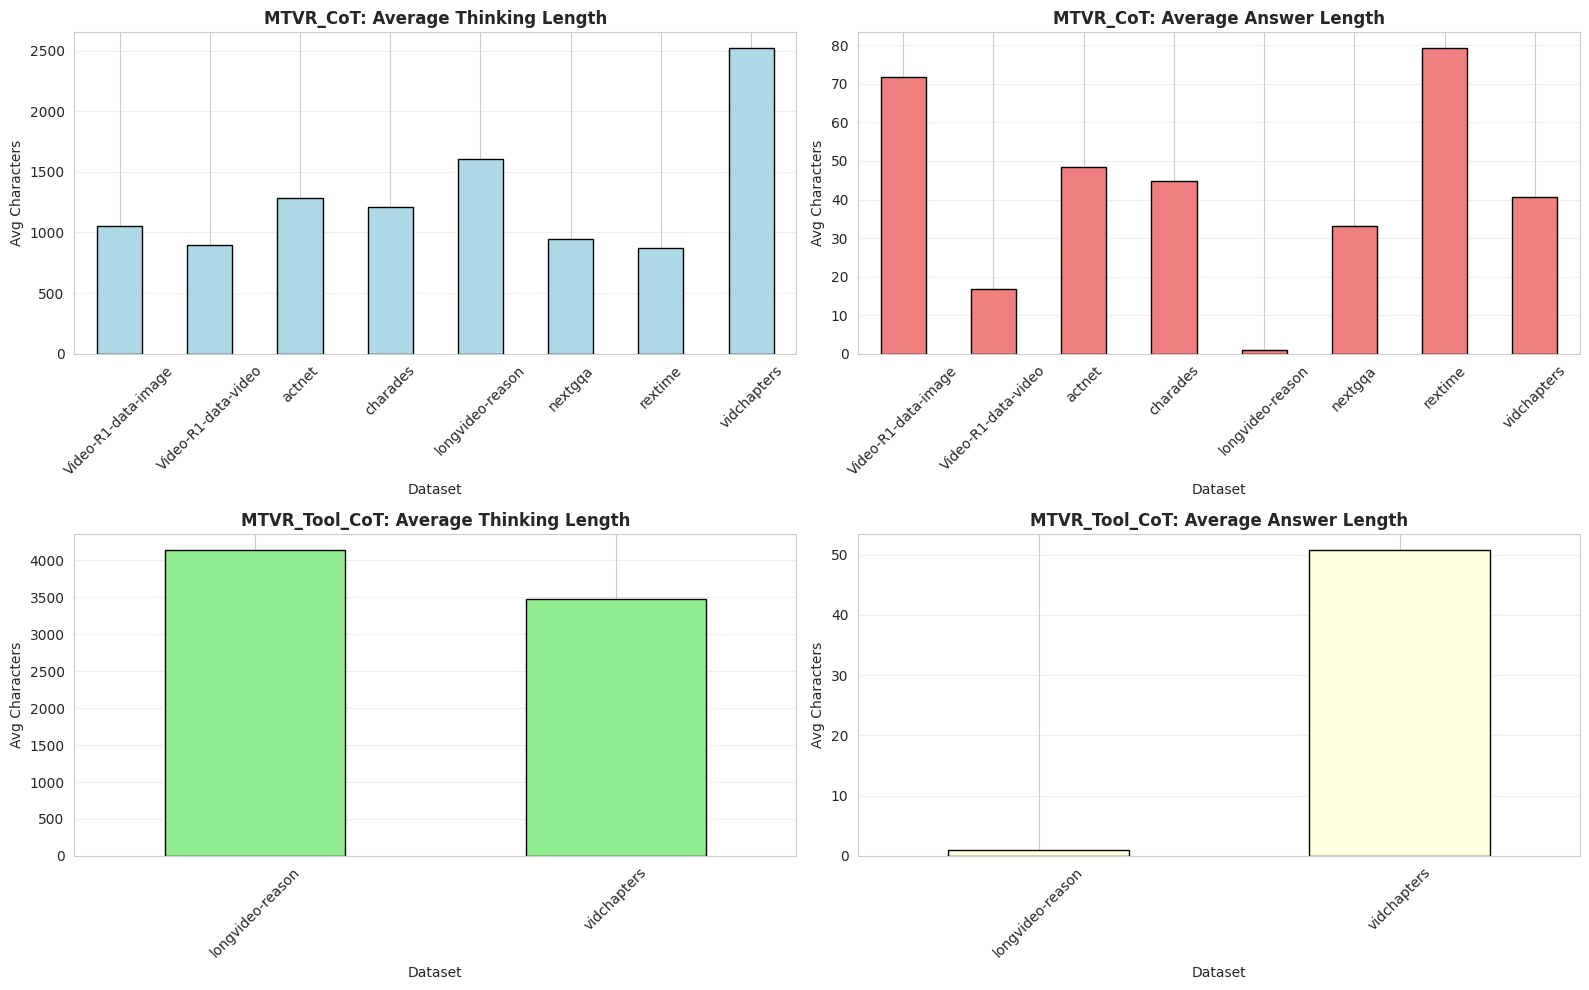


📝 SOLUTION LENGTH STATISTICS

MTVR_CoT - Average lengths:
                     think_length  answer_length  total_length
dataset                                                       
Video-R1-data-image   1055.769994      71.684811   1127.454805
Video-R1-data-video    898.024453      16.698842    914.723295
actnet                1283.066779      48.321045   1331.387824
charades              1206.977470      44.762066   1251.739536
longvideo-reason      1608.274325       1.000000   1609.274325
nextgqa                944.939424      33.177756    978.117180
rextime                868.061648      79.397163    947.458811
vidchapters           2524.583744      40.627202   2565.210947

MTVR_Tool_CoT - Average lengths:
                  think_length  answer_length  total_length
dataset                                                    
longvideo-reason   4144.472574       1.000285   4145.472859
vidchapters        3480.926592      50.784505   3531.711096


In [ ]:
# Visualization 4: Solution Length Analysis (thinking + answer)
def extract_thinking_and_answer(solution):
    """Extract thinking and answer parts from solution."""
    if isinstance(solution, str):
        think_match = re.search(r'<think>(.*?)</think>', solution, re.DOTALL)
        answer_match = re.search(r'<answer>(.*?)</answer>', solution, re.DOTALL)
        
        think_len = len(think_match.group(1).strip()) if think_match else 0
        answer_len = len(answer_match.group(1).strip()) if answer_match else 0
        
        return think_len, answer_len
    elif isinstance(solution, list):
        # For Tool_CoT data, solution is a list
        total_think = 0
        total_answer = 0
        for item in solution:
            think_len, answer_len = extract_thinking_and_answer(item)
            total_think += think_len
            total_answer += answer_len
        return total_think, total_answer
    return 0, 0

# Analyze solution lengths
solution_stats_cot = []
for dataset_name, data in mtvr_cot_data.items():
    for sample in data:
        think_len, answer_len = extract_thinking_and_answer(sample.get('solution', ''))
        solution_stats_cot.append({
            'dataset': dataset_name,
            'think_length': think_len,
            'answer_length': answer_len,
            'total_length': think_len + answer_len
        })

df_solution_cot = pd.DataFrame(solution_stats_cot)

solution_stats_tool = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        think_len, answer_len = extract_thinking_and_answer(sample.get('solution', []))
        solution_stats_tool.append({
            'dataset': dataset_name,
            'think_length': think_len,
            'answer_length': answer_len,
            'total_length': think_len + answer_len
        })

df_solution_tool = pd.DataFrame(solution_stats_tool)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CoT thinking length
df_solution_cot.groupby('dataset')['think_length'].mean().plot(kind='bar', ax=axes[0, 0], color='lightblue', edgecolor='black')
axes[0, 0].set_title('MTVR_CoT: Average Thinking Length', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Dataset')
axes[0, 0].set_ylabel('Avg Characters')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# CoT answer length
df_solution_cot.groupby('dataset')['answer_length'].mean().plot(kind='bar', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('MTVR_CoT: Average Answer Length', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Dataset')
axes[0, 1].set_ylabel('Avg Characters')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Tool_CoT thinking length
df_solution_tool.groupby('dataset')['think_length'].mean().plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('MTVR_Tool_CoT: Average Thinking Length', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Dataset')
axes[1, 0].set_ylabel('Avg Characters')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Tool_CoT answer length
df_solution_tool.groupby('dataset')['answer_length'].mean().plot(kind='bar', ax=axes[1, 1], color='lightyellow', edgecolor='black')
axes[1, 1].set_title('MTVR_Tool_CoT: Average Answer Length', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Dataset')
axes[1, 1].set_ylabel('Avg Characters')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📝 SOLUTION LENGTH STATISTICS")
print("="*60)
print("\nMTVR_CoT - Average lengths:")
print(df_solution_cot.groupby('dataset')[['think_length', 'answer_length', 'total_length']].mean())
print("\nMTVR_Tool_CoT - Average lengths:")
print(df_solution_tool.groupby('dataset')[['think_length', 'answer_length', 'total_length']].mean())
print("="*60)


/tmp/ipykernel_2291461/3501399771.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tool_analysis, x='dataset', y='clip_duration', ax=axes[0], palette='pastel')
/tmp/ipykernel_2291461/3501399771.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tool_analysis, x='dataset', y='coverage_ratio', ax=axes[1], palette='pastel')


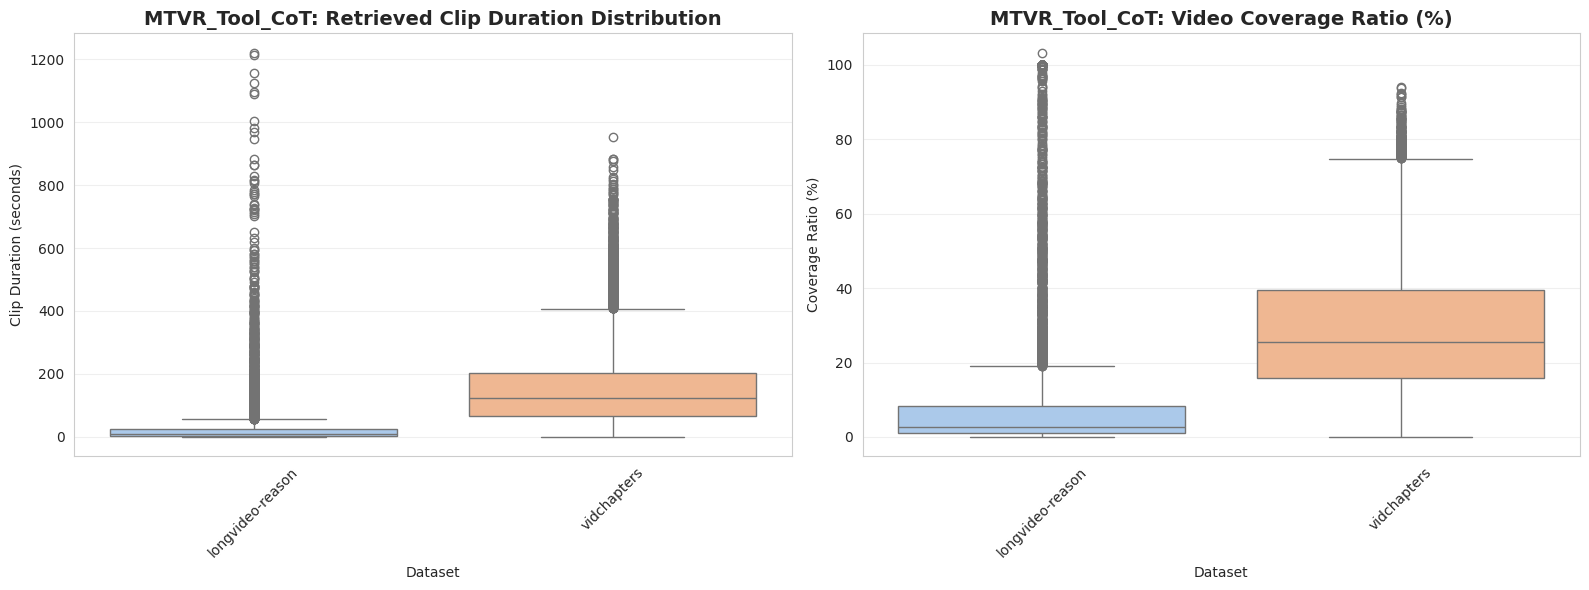


🛠️ TOOL CALLING STATISTICS

Retrieved Clip Statistics:
                 clip_duration                                             \
                         count        mean        std  min    25%     50%   
dataset                                                                     
longvideo-reason        7019.0   34.351542   87.37826  0.5   3.50   10.00   
vidchapters            10571.0  155.857818  131.27401  0.5  67.46  122.89   

                                   coverage_ratio                        \
                      75%      max          count       mean        std   
dataset                                                                   
longvideo-reason   25.000  1221.21         7019.0   9.673316  18.843462   
vidchapters       203.625   952.12        10571.0  28.744141  18.531018   

                                                                         
                       min        25%        50%        75%         max  
dataset                           

In [ ]:
# Visualization 5: Tool Calling Analysis (MTVR_Tool_CoT specific)
def extract_tool_params(tool_params_str):
    """Extract start and end times from tool_params."""
    try:
        params = json.loads(tool_params_str)
        if isinstance(params, list) and len(params) == 2:
            return params[0], params[1]
    except:
        pass
    return None, None

tool_analysis = []
for dataset_name, data in mtvr_tool_cot_data.items():
    for sample in data:
        start_time, end_time = extract_tool_params(sample.get('tool_params', '[]'))
        if start_time is not None and end_time is not None:
            clip_duration = end_time - start_time
            total_duration = sample.get('duration', 0)
            coverage_ratio = clip_duration / total_duration if total_duration > 0 else 0
            
            tool_analysis.append({
                'dataset': dataset_name,
                'clip_duration': clip_duration,
                'total_duration': total_duration,
                'coverage_ratio': coverage_ratio * 100  # percentage
            })

df_tool_analysis = pd.DataFrame(tool_analysis)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clip duration distribution
if not df_tool_analysis.empty:
    sns.boxplot(data=df_tool_analysis, x='dataset', y='clip_duration', ax=axes[0], palette='pastel')
    axes[0].set_title('MTVR_Tool_CoT: Retrieved Clip Duration Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Dataset')
    axes[0].set_ylabel('Clip Duration (seconds)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Coverage ratio distribution
    sns.boxplot(data=df_tool_analysis, x='dataset', y='coverage_ratio', ax=axes[1], palette='pastel')
    axes[1].set_title('MTVR_Tool_CoT: Video Coverage Ratio (%)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Dataset')
    axes[1].set_ylabel('Coverage Ratio (%)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🛠️ TOOL CALLING STATISTICS")
print("="*60)
if not df_tool_analysis.empty:
    print("\nRetrieved Clip Statistics:")
    print(df_tool_analysis.groupby('dataset')[['clip_duration', 'coverage_ratio']].describe())
print("="*60)


NameError: name 'cot_counts' is not defined

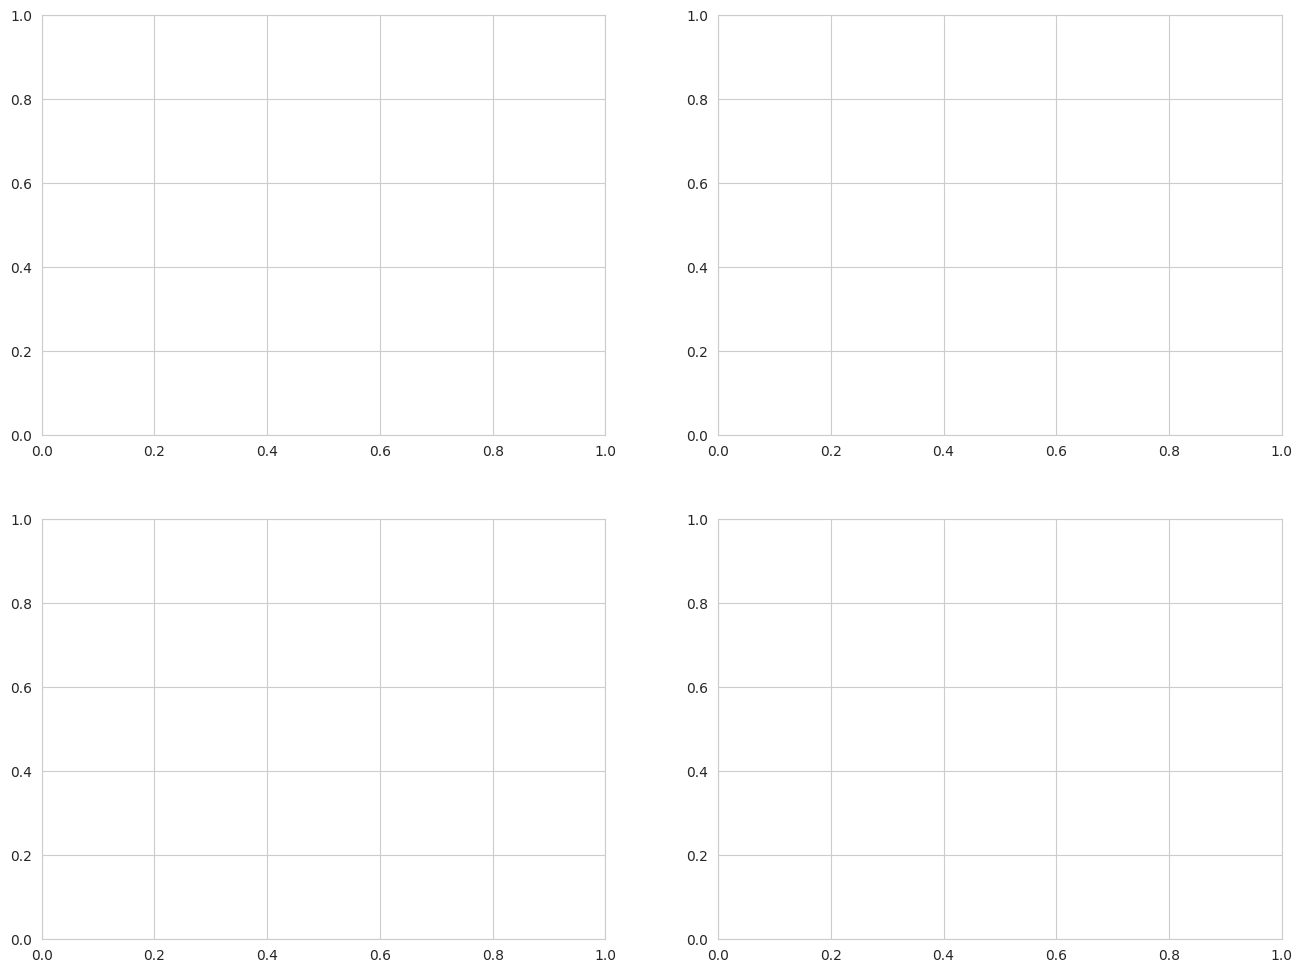

In [ ]:
# Visualization 6: Comprehensive Dataset Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total samples comparison
datasets = ['MTVR_CoT', 'MTVR_Tool_CoT']
total_samples = [sum(cot_counts.values()), sum(tool_cot_counts.values())]
colors = ['skyblue', 'coral']

axes[0, 0].bar(datasets, total_samples, color=colors, edgecolor='black', width=0.6)
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Total Samples Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(total_samples):
    axes[0, 0].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 2. Average video duration
if not df_durations_cot.empty and not df_durations_tool.empty:
    avg_durations = [
        df_durations_cot['duration'].mean(),
        df_durations_tool['duration'].mean()
    ]
    axes[0, 1].bar(datasets, avg_durations, color=colors, edgecolor='black', width=0.6)
    axes[0, 1].set_ylabel('Seconds')
    axes[0, 1].set_title('Average Video Duration', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(avg_durations):
        axes[0, 1].text(i, v + 5, f'{v:.1f}s', ha='center', va='bottom', fontweight='bold')

# 3. Average thinking length
avg_think = [
    df_solution_cot['think_length'].mean(),
    df_solution_tool['think_length'].mean()
]
axes[1, 0].bar(datasets, avg_think, color=colors, edgecolor='black', width=0.6)
axes[1, 0].set_ylabel('Characters')
axes[1, 0].set_title('Average Thinking Length', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_think):
    axes[1, 0].text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# 4. Average answer length
avg_answer = [
    df_solution_cot['answer_length'].mean(),
    df_solution_tool['answer_length'].mean()
]
axes[1, 1].bar(datasets, avg_answer, color=colors, edgecolor='black', width=0.6)
axes[1, 1].set_ylabel('Characters')
axes[1, 1].set_title('Average Answer Length', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_answer):
    axes[1, 1].text(i, v + 2, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final comprehensive summary
print("\n" + "="*70)
print("📊 COMPREHENSIVE DATASET SUMMARY")
print("="*70)
print(f"\n{'Metric':<40} {'MTVR_CoT':<15} {'MTVR_Tool_CoT':<15}")
print("-"*70)
print(f"{'Total Samples':<40} {sum(cot_counts.values()):<15,} {sum(tool_cot_counts.values()):<15,}")
print(f"{'Number of Source Datasets':<40} {len(cot_counts):<15} {len(tool_cot_counts):<15}")
print(f"{'Avg Video Duration (seconds)':<40} {df_durations_cot['duration'].mean():<15.2f} {df_durations_tool['duration'].mean():<15.2f}")
print(f"{'Avg Thinking Length (chars)':<40} {df_solution_cot['think_length'].mean():<15.0f} {df_solution_tool['think_length'].mean():<15.0f}")
print(f"{'Avg Answer Length (chars)':<40} {df_solution_cot['answer_length'].mean():<15.0f} {df_solution_tool['answer_length'].mean():<15.0f}")
print(f"{'Avg Total Solution Length (chars)':<40} {df_solution_cot['total_length'].mean():<15.0f} {df_solution_tool['total_length'].mean():<15.0f}")
print("="*70)

print("\n💡 KEY INSIGHTS:")
print("   • MTVR_Tool_CoT is a synthetic dataset with tool-augmented reasoning")
print("   • Tool calling enables targeted frame retrieval for better reasoning")
print("   • Both datasets use <think> and <answer> tags for structured reasoning")
print("   • The data covers diverse video understanding tasks across multiple domains")
print("="*70)


In [ ]:
# Bonus: Sample Data Exploration
print("="*70)
print("🔍 SAMPLE DATA EXAMPLES")
print("="*70)

# Show a sample from MTVR_CoT
print("\n" + "─"*70)
print("📄 MTVR_CoT Sample (actnet dataset):")
print("─"*70)
sample_cot = mtvr_cot_data['actnet'][0]
print(f"ID: {sample_cot['id']}")
print(f"Video: {sample_cot['video']}")
print(f"Duration: {sample_cot['duration']} seconds")
print(f"\nTask:\n{sample_cot['text'][:200]}...")
print(f"\nSolution structure:")
print(f"  - Has <think> tag: {'<think>' in sample_cot['solution']}")
print(f"  - Has <answer> tag: {'<answer>' in sample_cot['solution']}")
print(f"  - Total length: {len(sample_cot['solution'])} characters")

# Show a sample from MTVR_Tool_CoT
print("\n" + "─"*70)
print("🛠️ MTVR_Tool_CoT Sample (longvideo-reason dataset):")
print("─"*70)
sample_tool = mtvr_tool_cot_data['longvideo-reason'][0]
print(f"ID: {sample_tool['id']}")
print(f"Video: {sample_tool['video']}")
print(f"Duration: {sample_tool['duration']} seconds")
print(f"Tool Parameters: {sample_tool['tool_params']}")
print(f"\nTask:\n{sample_tool['text'][:200]}...")
print(f"\nSolution structure:")
print(f"  - Type: {type(sample_tool['solution'])}")
print(f"  - Number of reasoning steps: {len(sample_tool['solution'])}")
print(f"  - Has <tool_call> tag: {'<tool_call>' in str(sample_tool['solution'])}")

# Show video_kwargs
print(f"\nVideo kwargs:")
for key, value in sample_tool.get('video_kwargs', {}).items():
    print(f"  - {key}: {value}")

print("\n" + "="*70)
print("✅ Data analysis complete!")
print("="*70)


🔍 SAMPLE DATA EXAMPLES

──────────────────────────────────────────────────────────────────────
📄 MTVR_CoT Sample (actnet dataset):
──────────────────────────────────────────────────────────────────────
ID: 000000
Video: v_QOlSCBRmfWY.mp4
Duration: 82.73 seconds

Task:
Please find the visual event described by a sentence in the video, determining its starting and ending times. The format should be: 'The event happens in the start time - end time'. For example, The e...

Solution structure:
  - Has <think> tag: True
  - Has <answer> tag: True
  - Total length: 1548 characters

──────────────────────────────────────────────────────────────────────
🛠️ MTVR_Tool_CoT Sample (longvideo-reason dataset):
──────────────────────────────────────────────────────────────────────
ID: 000003
Video: JEnGmvnKggA.mp4
Duration: 403.52 seconds
Tool Parameters: [359.0, 394.0]

Task:
What is the primary goal of the person in the video, as inferred from the interaction dynamics, textual cues, and video compos

In [17]:
import pickle

with open("/data/user_data/jamesdin/data/vidchapters/tagged_video_ids.json", "rb") as f:
    all_data = pickle.load(f)

print(type(all_data))
print(len(all_data))


<class 'dict'>
817076


In [18]:
all_data['TdGLBI_lsig']

{'chapters': [{'label': 'Turbo and Cars', 'time': 40},
  {'label': 'Shrek and Monsters, Inc', 'time': 105},
  {'label': 'Madagascar and The Wild', 'time': 173},
  {'label': 'Home and Mars Needs Moms', 'time': 253},
  {'label': "The Road to El Dorado and The Emperor's New Groove", 'time': 320},
  {'label': 'Sinbad and Treasure Planet', 'time': 386},
  {'label': 'The Prince of Egypt and Mulan', 'time': 452},
  {'label': 'Flushed Away and Ratatouille', 'time': 522},
  {'label': "Antz and A Bug's Life", 'time': 595},
  {'label': 'Finding Nemo and Shark Tale', 'time': 655}],
 'duration': 746,
 'title': '10 Shocking Similarities Between Disney/Pixar And Dreamworks Films',
 'description': "10 Shocking Similarities Between Disney/Pixar And Dreamworks Films! Subscribe to our channel: http://goo.gl/ho3Hg6\n\nTry out ThePremium Network for free: https://goo.gl/URs6sk\n\nCheck Out These Other Amazing Videos:\n10 Times Disney Ripped Off Other Films - https://youtu.be/VhjDaCCyc50\n10 Popular Movie S

In [19]:
import json

with open("/data/user_data/jamesdin/data/vidchapters/train_video_ids.json", "rb") as f:
    train_data = json.load(f)

print(type(train_data))
print(len(train_data))

<class 'list'>
800676


In [20]:
# load the vidchapters.json file

with open("data/MultiTaskVideoReasoning/MTVR_Tool_CoT/vidchapters.json") as f:
    train_data = json.load(f)

# all video ids are used in the training dataset. download all of them. To get the video ids, 
for example in train_data:
    vid = example['video_id'].split('.')[0]
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/


with open("data/MultiTaskVideoReasoning/MTVR_Tool_CoT/vidchapters.json") as f:
    train_data = json.load(f)

# all video ids are used in the training dataset. download all of them. To get the video ids, 
downloaded = set()
for example in train_data:
    vid = example['video_id'].split('.')[0]
    if vid in downloaded:
        continue
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/
    

with open("/data/user_data/jamesdin/data/vidchapters/val_video_ids.json", "rb") as f:
    val_video_ids = json.load(f)

with open("/data/user_data/jamesdin/data/vidchapters/test_video_ids.json", "rb") as f:
    test_video_ids = json.load(f)

for vid in val_video_ids + test_video_ids:
    if vid in downloaded:
        continue
    # download the video from youtube using yt-dlp
    # output path should be data/vidchapters/raw_videos/
    




KeyError: 'video_id'

In [ ]:
val_video_ids '--5egaUoMpY'


True